# Automatska klasifikacija IT support tiketa pomoću neuronskih mreža

Ovaj projekat prikazuje kompletan tok izrade sistema koji na osnovu opisa IT support tiketa automatski predviđa njegovu kategoriju. U praksi ovakav sistem može da ubrza rad help desk tima, da automatski usmerava zahteve ka odgovarajućem timu i da smanji vreme ručne obrade tiketa.

U notebook-u će biti obrađeni sledeći koraci:
- preuzimanje dataseta direktno sa Kaggle-a preko API-ja,
- učitavanje i analiza podataka,
- čišćenje teksta i priprema labela,
- baseline model sa TF-IDF reprezentacijom,
- neuronska mreža za tekstualnu klasifikaciju,
- eksperimenti sa različitim hiperparametrima,
- evaluacija metrikama `accuracy`, `precision`, `recall` i `F1-score`,
- čuvanje najboljeg modela i predikcija novih tiketa.

Krajnji rezultat projekta je model koji direktno prima sirov tekst tiketa i vraća predviđenu kategoriju zajedno sa pouzdanošću predikcije.


## 1. Uvod

Klasifikacija IT support tiketa predstavlja zadatak višeklasne klasifikacije teksta. Ulaz u model je opis problema koji je korisnik prijavio, a izlaz je jedna od unapred definisanih kategorija, na primer `Access`, `Hardware`, `Software`, `Network` i slično.

Za evaluaciju ćemo koristiti:
- `accuracy` kao opštu tačnost klasifikacije,
- `precision macro` da proverimo koliko su predikcije po klasama precizne,
- `recall macro` da proverimo koliko dobro model pronalazi primere svake klase,
- `F1 macro` kao balans između precision i recall vrednosti.

Fokus projekta je na praktičnoj implementaciji razumljive neuronske mreže, pogodnoj za studentsku odbranu projekta.


In [ ]:
import os
import re
import json
import random
import shutil
import subprocess
import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import sklearn

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Conv1D,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PLOTS_DIR = PROJECT_ROOT / "plots"

for folder in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR, PLOTS_DIR]:
    folder.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


## 2. Import biblioteka i podešavanja

U ovoj sekciji učitavamo biblioteke potrebne za rad sa podacima, baseline model, neuronske mreže i vizualizacije. Takođe postavljamo `seed` vrednost radi ponovljivosti rezultata i kreiramo foldere za modele, izlaze i grafikone.


In [ ]:
print(f"Python verzija: {platform.python_version()}")
print(f"TensorFlow verzija: {tf.__version__}")
print(f"pandas verzija: {pd.__version__}")
print(f"scikit-learn verzija: {sklearn.__version__}")
print(f"Radni direktorijum: {PROJECT_ROOT.resolve()}")


Python verzija: 3.12.13
TensorFlow verzija: 2.20.0
pandas verzija: 2.2.2
scikit-learn verzija: 1.6.1
Radni direktorijum: /content


## 3. Kaggle API podesavanje i preuzimanje dataseta

Dataset se **ne cuva unapred u repozitorijumu**, vec se preuzima tokom izvrsavanja notebook-a pomocu Kaggle API-ja. Ovo je prakticno za Google Colab, ali treba imati u vidu da ce se sadrzaj foldera `data/` izgubiti nakon resetovanja runtime-a.

U ovoj verziji notebook-a Kaggle kredencijali su upisani direktno u kod, a zatim se pre poziva Kaggle CLI executable-a postavljaju kroz environment promenljive.

**Bezbednosna napomena:** ovaj notebook sada sadrzi privatni Kaggle API token direktno u kodu. Ne treba ga deliti javno niti commitovati na GitHub.


In [ ]:
import importlib.util

KAGGLE_USERNAME = 'mihajlodunjic'
KAGGLE_KEY = ''
KAGGLE_DATASET = "adisongoh/it-service-ticket-classification-dataset"
CSV_PATH_OVERRIDE = None

# Ako menjate Kaggle nalog ili dataset, promenite vrednosti ovde.
# Primer formata za dataset slug:
# KAGGLE_DATASET = "owner/dataset-name"


def ensure_kaggle_installed():
    if importlib.util.find_spec("kaggle") is None:
        print("Instaliram Kaggle biblioteku...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
        print("Kaggle biblioteka je uspesno instalirana.")
    else:
        print("Kaggle biblioteka je vec dostupna.")


In [ ]:
def configure_kaggle_auth():
    if not KAGGLE_USERNAME or not KAGGLE_KEY:
        raise ValueError("KAGGLE_USERNAME i KAGGLE_KEY moraju biti postavljeni u notebook-u.")

    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
    os.environ["KAGGLE_KEY"] = KAGGLE_KEY

    return {
        "username_set": bool(os.environ.get("KAGGLE_USERNAME")),
        "key_set": bool(os.environ.get("KAGGLE_KEY")),
    }


def get_kaggle_command():
    kaggle_command = shutil.which("kaggle")
    if kaggle_command:
        return kaggle_command

    python_dir = Path(sys.executable).resolve().parent
    candidate_paths = [
        python_dir / "kaggle",
        python_dir / "Scripts" / "kaggle.exe",
        Path("/usr/local/bin/kaggle"),
        Path("/usr/bin/kaggle"),
    ]

    for candidate in candidate_paths:
        if candidate.exists():
            return str(candidate)

    raise FileNotFoundError(
        "Kaggle CLI executable nije pronadjen. Proverite da li je paket instaliran i da li je komanda 'kaggle' dostupna u runtime-u."
    )


def download_kaggle_dataset(dataset_slug, data_dir):
    placeholder_values = {
        "OVDE_UNESI_TACAN_KAGGLE_DATASET_SLUG",
        "unesi-vlasnika/unesi-naziv-dataseta",
        "",
        None,
    }

    if dataset_slug in placeholder_values or "unesi-vlasnika" in str(dataset_slug).lower():
        raise ValueError(
            "KAGGLE_DATASET nije podesen. Unesite tacan Kaggle dataset slug u promenljivu KAGGLE_DATASET."
        )

    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    kaggle_command = get_kaggle_command()

    command = [
        kaggle_command,
        "datasets",
        "download",
        "-d",
        dataset_slug,
        "-p",
        str(data_dir),
        "--unzip",
        "--force",
    ]

    try:
        completed = subprocess.run(
            command,
            check=True,
            capture_output=True,
            text=True,
            env=os.environ.copy(),
        )
        stdout = completed.stdout.strip()
        stderr = completed.stderr.strip()
        if stdout:
            print(stdout)
        if stderr:
            print(stderr)
    except FileNotFoundError as exc:
        raise RuntimeError(
            "Kaggle CLI executable nije dostupan. Proverite da li je biblioteka instalirana i restartujte runtime ako je potrebno."
        ) from exc
    except subprocess.CalledProcessError as exc:
        error_message = exc.stderr.strip() or exc.stdout.strip() or str(exc)
        raise RuntimeError(
            "Preuzimanje dataseta nije uspelo. Proverite da li su KAGGLE_USERNAME i KAGGLE_KEY ispravni i da li API token ima pristup datasetu. "
            f"Kaggle API poruka: {error_message}"
        ) from exc

    return data_dir


In [ ]:
ensure_kaggle_installed()
kaggle_auth_status = configure_kaggle_auth()
print(f"Kaggle API je podesen. Username set: {kaggle_auth_status['username_set']}, key set: {kaggle_auth_status['key_set']}")

download_kaggle_dataset(KAGGLE_DATASET, DATA_DIR)
print(f"Dataset je preuzet u direktorijum: {DATA_DIR.resolve()}")


Kaggle biblioteka je vec dostupna.
Kaggle API je podesen. Username set: True, key set: True
Dataset URL: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset
License(s): CC0-1.0
0%|          | 0.00/3.45M [00:00<?, ?B/s]
100%|██████████| 3.45M/3.45M [00:00<00:00, 255MB/s]
Dataset je preuzet u direktorijum: /content/data


## 4. Učitavanje dataseta

Nakon preuzimanja, potrebno je da pronađemo CSV fajl koji sadrži podatke. Pošto Kaggle dataset može da sadrži više fajlova, implementiramo funkciju koja rekurzivno pretražuje `data/` folder i bira najlogičniji CSV na osnovu naziva i veličine fajla.


In [ ]:
def find_csv_file(data_dir):
    data_dir = Path(data_dir)
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(
            "CSV fajl nije pronađen nakon preuzimanja dataseta. Proverite sadržaj foldera data/."
        )

    if len(csv_files) == 1:
        print(f"Pronađen je jedan CSV fajl: {csv_files[0]}")
        return csv_files[0]

    print("Pronađeno je više CSV fajlova:")
    for csv_path in csv_files:
        size_kb = csv_path.stat().st_size / 1024
        print(f"- {csv_path} ({size_kb:.2f} KB)")

    preferred_keywords = [
        "ticket",
        "tickets",
        "support",
        "service",
        "classification",
        "data",
    ]

    scored_files = []
    for csv_path in csv_files:
        name = csv_path.name.lower()
        score = sum(2 for keyword in preferred_keywords if keyword in name)
        if "train" not in name and "test" not in name and "sample" not in name:
            score += 1
        scored_files.append((score, csv_path.stat().st_size, csv_path))

    scored_files.sort(key=lambda item: (item[0], item[1]), reverse=True)
    best_score, best_size, best_csv = scored_files[0]

    ambiguous_candidates = [
        path
        for score, size, path in scored_files
        if score == best_score and size == best_size
    ]

    if len(ambiguous_candidates) > 1:
        raise ValueError(
            "Pronađeno je više podjednako dobrih CSV fajlova. Ručno podesite CSV_PATH_OVERRIDE."
        )

    print(f"Izabrani CSV fajl: {best_csv}")
    return best_csv


if CSV_PATH_OVERRIDE is not None:
    CSV_PATH = Path(CSV_PATH_OVERRIDE)
    print(f"CSV putanja je ručno podešena na: {CSV_PATH}")
else:
    CSV_PATH = find_csv_file(DATA_DIR)

try:
    df = pd.read_csv(CSV_PATH, low_memory=False)
except UnicodeDecodeError:
    df = pd.read_csv(CSV_PATH, encoding="latin-1", low_memory=False)

print(f"Učitani CSV fajl: {CSV_PATH}")
display(df.head())
print(f"Broj redova i kolona: {df.shape}")
print(f"Nazivi kolona: {df.columns.tolist()}")
print("\nTipovi podataka po koloni:")
display(df.dtypes.astype(str).rename("dtype").to_frame())
print("Broj nedostajućih vrednosti po koloni:")
display(df.isna().sum().rename("missing_values").to_frame())
print("Sažetak preko df.info():")
df.info()


Pronađen je jedan CSV fajl: data/all_tickets_processed_improved_v3.csv
Učitani CSV fajl: data/all_tickets_processed_improved_v3.csv


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Broj redova i kolona: (47837, 2)
Nazivi kolona: ['Document', 'Topic_group']

Tipovi podataka po koloni:


,dtype
Document,object
Topic_group,object


Broj nedostajućih vrednosti po koloni:


,missing_values
Document,0
Topic_group,0


Sažetak preko df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


## 5. Izbor tekstualne i ciljne kolone

Za trening modela potrebne su nam dve glavne kolone:
- tekst tiketa,
- kategorija tiketa.

Ako nazivi kolona nisu standardni, notebook pokušava automatsku detekciju. Ako detekcija nije sigurna, moguće je ručno podesiti nazive u promenljivama `TEXT_COLUMN` i `LABEL_COLUMN`.


In [ ]:
TEXT_COLUMN = None
LABEL_COLUMN = None

# Ako automatska detekcija ne pronađe prave kolone, ručno ih podesite ovde.
# TEXT_COLUMN = "Document"
# LABEL_COLUMN = "Topic_group"


def normalize_column_name(column_name):
    return re.sub(r"[^a-z0-9]+", " ", str(column_name).strip().lower()).strip()


def detect_columns(df):
    text_candidates = [
        "text",
        "ticket text",
        "ticket_text",
        "description",
        "ticket description",
        "request",
        "issue",
        "problem",
        "body",
        "content",
        "summary",
        "document",
    ]
    label_candidates = [
        "category",
        "label",
        "class",
        "type",
        "queue",
        "group",
        "topic",
        "topic group",
        "department",
        "target",
    ]

    stats = []
    for column in df.columns:
        series = df[column].dropna().astype(str)
        if series.empty:
            avg_length = 0.0
            unique_count = 0
        else:
            avg_length = series.str.len().mean()
            unique_count = series.nunique()

        stats.append(
            {
                "column": column,
                "normalized": normalize_column_name(column),
                "avg_length": avg_length,
                "unique_count": unique_count,
                "dtype": str(df[column].dtype),
            }
        )

    stats_df = pd.DataFrame(stats)

    def candidate_score(row, candidates, prefer_long_text=False):
        name_score = 0
        for candidate in candidates:
            candidate_norm = normalize_column_name(candidate)
            if row["normalized"] == candidate_norm:
                name_score = max(name_score, 5)
            elif candidate_norm in row["normalized"]:
                name_score = max(name_score, 3)

        dtype_score = 1 if "object" in row["dtype"] or "string" in row["dtype"] else 0

        if prefer_long_text:
            length_score = 2 if row["avg_length"] >= 25 else 1 if row["avg_length"] >= 10 else 0
            uniqueness_score = 1 if row["unique_count"] > 20 else 0
            return name_score + dtype_score + length_score + uniqueness_score

        uniqueness_score = 2 if 2 <= row["unique_count"] <= max(10, len(df) * 0.2) else 0
        length_score = 1 if row["avg_length"] <= 40 else 0
        return name_score + dtype_score + uniqueness_score + length_score

    stats_df["text_score"] = stats_df.apply(
        lambda row: candidate_score(row, text_candidates, prefer_long_text=True), axis=1
    )
    stats_df["label_score"] = stats_df.apply(
        lambda row: candidate_score(row, label_candidates, prefer_long_text=False), axis=1
    )

    best_text_row = stats_df.sort_values(["text_score", "avg_length"], ascending=[False, False]).iloc[0]
    best_label_row = stats_df.sort_values(["label_score", "unique_count"], ascending=[False, True]).iloc[0]

    if best_text_row["column"] == best_label_row["column"]:
        raise ValueError(
            "Automatska detekcija nije uspela jer je ista kolona izabrana i za tekst i za labelu. Ručno podesite TEXT_COLUMN i LABEL_COLUMN."
        )

    if best_text_row["text_score"] < 2 or best_label_row["label_score"] < 2:
        print("Nazivi kolona u datasetu:")
        print(df.columns.tolist())
        print("\nPomoćna tabela za detekciju:")
        display(stats_df.sort_values("column"))
        raise ValueError(
            "Automatska detekcija kolona nije dovoljno sigurna. Ručno podesite TEXT_COLUMN i LABEL_COLUMN."
        )

    return best_text_row["column"], best_label_row["column"], stats_df


if TEXT_COLUMN is None or LABEL_COLUMN is None:
    detected_text_column, detected_label_column, detected_columns_df = detect_columns(df)
    print("Rezultat automatske detekcije kolona:")
    display(detected_columns_df.sort_values(["text_score", "label_score"], ascending=False))
    TEXT_COLUMN = TEXT_COLUMN or detected_text_column
    LABEL_COLUMN = LABEL_COLUMN or detected_label_column

print(f"Izabrana tekstualna kolona: {TEXT_COLUMN}")
print(f"Izabrana label kolona: {LABEL_COLUMN}")

data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ["text", "category"]
display(data.head())


Rezultat automatske detekcije kolona:


,column,normalized,avg_length,unique_count,dtype,text_score,label_score
0,Document,document,291.881263,47837,object,9,1
1,Topic_group,topic group,9.670987,8,object,1,9


Izabrana tekstualna kolona: Document
Izabrana label kolona: Topic_group


,text,category
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


## 6. Pregled i analiza podataka

Pre treniranja modela važno je da razumemo dataset:
- koliko primera imamo,
- koliko postoji kategorija,
- da li su klase balansirane,
- kolika je dužina tekstova.

Neravnoteža između klasa može da utiče na precision, recall i F1-score, pa je korisno da to proverimo na početku.


Broj primera: 47837
Broj kategorija: 8


,broj_primera,procenat
category,,
Hardware,13617,28.47
HR Support,10915,22.82
Access,7125,14.89
Miscellaneous,7060,14.76
Storage,2777,5.81
Purchase,2464,5.15
Internal Project,2119,4.43
Administrative rights,1760,3.68


Prosečna dužina teksta: 43.60 reči
Minimalna dužina teksta: 2 reči
Maksimalna dužina teksta: 981 reči


/tmp/ipykernel_14802/3993238822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


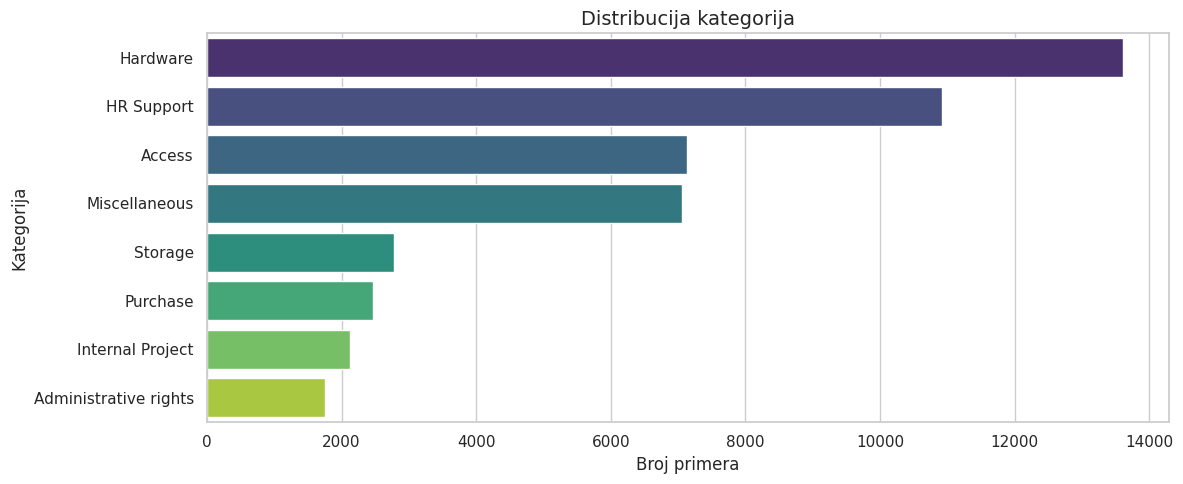

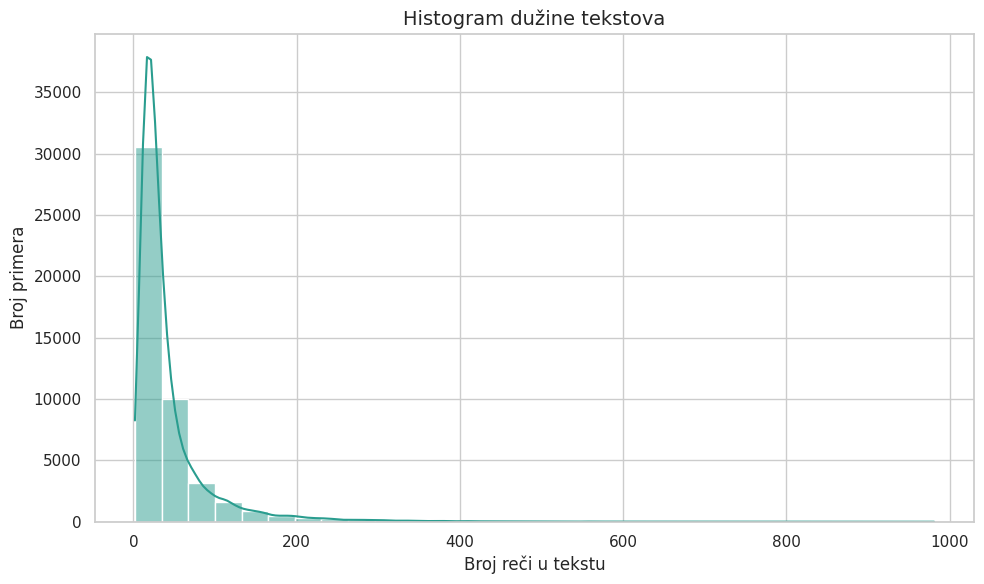

,text
0,18
1,19
2,14
3,145
4,15
...,...
47832,155
47833,22
47834,59
47835,57


In [ ]:
def plot_class_distribution(data, save_path=None):
    class_counts = data["category"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(12, max(5, len(class_counts) * 0.45)))
    sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
    plt.title("Distribucija kategorija")
    plt.xlabel("Broj primera")
    plt.ylabel("Kategorija")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return class_counts


def plot_text_lengths(data, text_column="text", save_path=None):
    text_lengths = data[text_column].astype(str).str.split().map(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(text_lengths, bins=30, kde=True, color="#2a9d8f")
    plt.title("Histogram dužine tekstova")
    plt.xlabel("Broj reči u tekstu")
    plt.ylabel("Broj primera")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return text_lengths


print(f"Broj primera: {len(data)}")
print(f"Broj kategorija: {data['category'].nunique()}")

class_counts = data["category"].value_counts()
class_percentages = (class_counts / len(data) * 100).round(2)
class_summary = pd.DataFrame(
    {
        "broj_primera": class_counts,
        "procenat": class_percentages,
    }
)
display(class_summary)

text_lengths = data["text"].astype(str).str.split().map(len)
print(f"Prosečna dužina teksta: {text_lengths.mean():.2f} reči")
print(f"Minimalna dužina teksta: {text_lengths.min()} reči")
print(f"Maksimalna dužina teksta: {text_lengths.max()} reči")

plot_class_distribution(data, PLOTS_DIR / "class_distribution.png")
plot_text_lengths(data, "text", PLOTS_DIR / "text_lengths.png")


## 7. Čišćenje podataka

Tekstualni podaci često sadrže nepotrebne razmake, URL-ove, email adrese i specijalne karaktere. Cilj čišćenja nije da uklonimo svaku informaciju, već da zadržimo ključne IT pojmove kao što su `password`, `printer`, `vpn`, `server`, `network` i slični izrazi.


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


initial_rows = len(data)

data["text"] = data["text"].fillna("").astype(str).str.strip()
data["category"] = data["category"].fillna("").astype(str).str.strip()

data = data[(data["text"] != "") & (data["category"] != "")].copy()
rows_after_missing = len(data)

data["clean_text"] = data["text"].apply(clean_text)
data = data[data["clean_text"].str.len() > 0].copy()

data = data.drop_duplicates(subset=["clean_text", "category"]).copy()
rows_after_duplicates = len(data)

print(f"Broj redova pre čišćenja: {initial_rows}")
print(f"Broj redova posle uklanjanja praznih vrednosti: {rows_after_missing}")
print(f"Broj redova posle uklanjanja duplikata: {rows_after_duplicates}")

display(data[["text", "clean_text", "category"]].head())


Broj redova pre čišćenja: 47837
Broj redova posle uklanjanja praznih vrednosti: 47837
Broj redova posle uklanjanja duplikata: 47837


,text,clean_text,category
0,connection with icon icon dear please setup ic...,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,mail verification warning hi has got attached ...,Miscellaneous


## 8. Pretvaranje kategorija u numerički oblik

Model ne može direktno da radi sa tekstualnim nazivima kategorija, pa svaku kategoriju pretvaramo u numeričku labelu pomoću `LabelEncoder` klase. Mapiranje čuvamo u JSON fajl da bismo kasnije mogli da prevedemo numerički izlaz modela nazad u naziv kategorije.


In [ ]:
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["category"])

label_names = label_encoder.classes_.tolist()
id_to_label = {str(index): label for index, label in enumerate(label_names)}
label_to_id = {label: index for index, label in enumerate(label_names)}
label_mapping = {
    "id_to_label": id_to_label,
    "label_to_id": label_to_id,
}

with open(MODELS_DIR / "label_mapping.json", "w", encoding="utf-8") as file:
    json.dump(label_mapping, file, ensure_ascii=False, indent=2)

label_mapping_df = pd.DataFrame(
    {
        "label_id": list(range(len(label_names))),
        "category": label_names,
    }
)
display(label_mapping_df)
print(f"Mapiranje labela je sačuvano u: {MODELS_DIR / 'label_mapping.json'}")


,label_id,category
0,0,Access
1,1,Administrative rights
2,2,HR Support
3,3,Hardware
4,4,Internal Project
5,5,Miscellaneous
6,6,Purchase
7,7,Storage


Mapiranje labela je sačuvano u: models/label_mapping.json


## 9. Podela podataka

Podatke delimo na tri dela:
- trening skup (`70%`),
- validacioni skup (`15%`),
- test skup (`15%`).

Kada god je moguće, koristimo `stratify` kako bi raspodela klasa ostala slična u svim podskupovima. Ako neka klasa ima premalo primera, notebook automatski prelazi na fallback bez stratifikacije.


In [ ]:
def split_dataset(data, random_state=SEED):
    try:
        train_df, temp_df = train_test_split(
            data,
            test_size=0.30,
            random_state=random_state,
            stratify=data["label"],
        )

        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            random_state=random_state,
            stratify=temp_df["label"],
        )
        split_mode = "stratify"
    except ValueError as exc:
        print(f"Upozorenje: stratified split nije uspeo ({exc}). Koristi se fallback bez stratify.")
        train_df, temp_df = train_test_split(
            data,
            test_size=0.30,
            random_state=random_state,
            stratify=None,
        )
        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            random_state=random_state,
            stratify=None,
        )
        split_mode = "bez stratify"

    return train_df.copy(), val_df.copy(), test_df.copy(), split_mode


train_df, val_df, test_df, split_mode = split_dataset(data)
print(f"Način podele: {split_mode}")
print(f"Train skup: {train_df.shape}")
print(f"Validation skup: {val_df.shape}")
print(f"Test skup: {test_df.shape}")

split_distribution_counts = pd.concat(
    {
        "train": train_df["category"].value_counts(),
        "validation": val_df["category"].value_counts(),
        "test": test_df["category"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

split_distribution_percentages = (
    split_distribution_counts.div(split_distribution_counts.sum(axis=0), axis=1) * 100
).round(2)

print("Distribucija klasa po skupovima (broj primera):")
display(split_distribution_counts)
print("Distribucija klasa po skupovima (procenti):")
display(split_distribution_percentages)


Način podele: stratify
Train skup: (33485, 4)
Validation skup: (7176, 4)
Test skup: (7176, 4)
Distribucija klasa po skupovima (broj primera):


,train,validation,test
category,,,
Hardware,9532,2043,2042
HR Support,7640,1637,1638
Access,4987,1069,1069
Miscellaneous,4942,1059,1059
Storage,1944,417,416
Purchase,1725,369,370
Internal Project,1483,318,318
Administrative rights,1232,264,264


Distribucija klasa po skupovima (procenti):


,train,validation,test
category,,,
Hardware,28.47,28.47,28.46
HR Support,22.82,22.81,22.83
Access,14.89,14.90,14.90
Miscellaneous,14.76,14.76,14.76
Storage,5.81,5.81,5.80
Purchase,5.15,5.14,5.16
Internal Project,4.43,4.43,4.43
Administrative rights,3.68,3.68,3.68


## 10. Tokenizacija i vektorizacija

Neuronska mreža ne može direktno da obrađuje sirov tekst, pa tekst prvo pretvaramo u niz celobrojnih tokena. To radi `TextVectorization` sloj:
- tokenizacija deli tekst na reči,
- vektorizacija svakoj reči dodeljuje numerički identifikator,
- svi tekstovi se skraćuju ili dopunjuju na istu dužinu da bi model mogao da ih primi kao ulaz.

Važno je da se `TextVectorization` adaptira samo na trening skupu, kako ne bismo "procurili" informacije iz validacionog i test skupa.


In [ ]:
MAX_TOKENS = 10_000
SEQUENCE_LENGTH = 100


def create_vectorizer(train_texts, max_tokens, sequence_length):
    vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize=None,
    )
    vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_texts).batch(128))
    return vectorizer


X_train = train_df["clean_text"].astype(str).values
y_train = train_df["label"].values

X_val = val_df["clean_text"].astype(str).values
y_val = val_df["label"].values

X_test = test_df["clean_text"].astype(str).values
y_test = test_df["label"].values

num_classes = len(label_names)

vectorizer = create_vectorizer(X_train, MAX_TOKENS, SEQUENCE_LENGTH)
sample_original_text = train_df.iloc[0]["text"]
sample_clean_text = train_df.iloc[0]["clean_text"]
sample_vectorized_text = vectorizer(tf.constant([sample_clean_text])).numpy()[0][:30]

print("Primer originalnog teksta:")
print(sample_original_text)
print("\nPrimer očišćenog teksta:")
print(sample_clean_text)
print("\nPrvih 30 tokena vektorizovanog teksta:")
print(sample_vectorized_text)
print(f"Veličina vokabulara: {len(vectorizer.get_vocabulary())}")


Primer originalnog teksta:
increase drive space at pc increase drive pc hello disc almost extend please kind regards engineer

Primer očišćenog teksta:
increase drive space at pc increase drive pc hello disc almost extend please kind regards engineer

Prvih 30 tokena vektorizovanog teksta:
[ 593  473  449 1617  387  593  473  387    8 4336  609  972    2   14
    5   33    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
Veličina vokabulara: 10000


## 11. Baseline model

Baseline model služi kao referentna tačka. Ako neuronska mreža ne daje bolje rezultate od jednostavnijeg pristupa, to je važan signal da arhitekturu ili pripremu podataka treba poboljšati.

Kao baseline koristimo:
- `TF-IDF` za reprezentaciju teksta,
- `LogisticRegression` kao klasični klasifikator.


Baseline - klasifikacioni izveštaj:
                       precision    recall  f1-score   support

               Access       0.91      0.85      0.88      1069
Administrative rights       0.64      0.86      0.73       264
           HR Support       0.89      0.85      0.87      1638
             Hardware       0.86      0.82      0.84      2042
     Internal Project       0.81      0.94      0.87       318
        Miscellaneous       0.79      0.86      0.82      1059
             Purchase       0.92      0.91      0.91       370
              Storage       0.85      0.91      0.88       416

             accuracy                           0.85      7176
            macro avg       0.83      0.87      0.85      7176
         weighted avg       0.86      0.85      0.85      7176



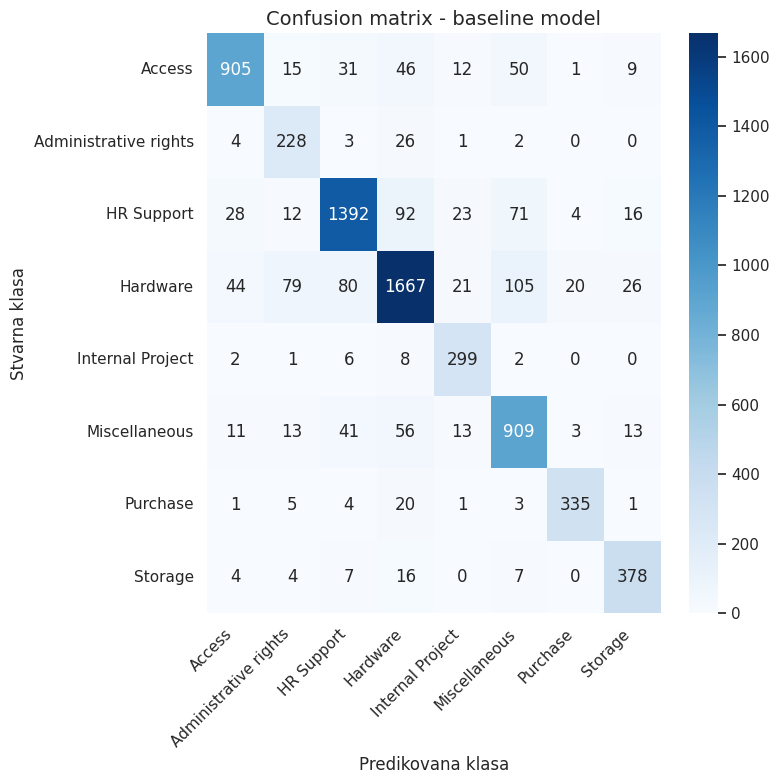

{'model': 'TF-IDF + Logistic Regression',
 'accuracy': 0.8518673355629878,
 'precision_macro': 0.8341548989297959,
 'recall_macro': 0.8736328856356064,
 'f1_macro': 0.8506078538108122}

In [ ]:
def calculate_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }


def plot_confusion_matrix(y_true, y_pred, label_names, title, save_path=None):
    labels = list(range(len(label_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    figure_size = max(8, int(len(label_names) * 0.8))
    plt.figure(figsize=(figure_size, figure_size))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.title(title)
    plt.xlabel("Predikovana klasa")
    plt.ylabel("Stvarna klasa")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return cm


results = []
history_store = {}

baseline_vectorizer = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))
X_train_tfidf = baseline_vectorizer.fit_transform(X_train)
X_test_tfidf = baseline_vectorizer.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)
baseline_metrics = calculate_metrics(y_test, baseline_predictions)
baseline_result = {"model": "TF-IDF + Logistic Regression", **baseline_metrics}
results.append(baseline_result)

print("Baseline - klasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        baseline_predictions,
        labels=list(range(len(label_names))),
        target_names=label_names,
        zero_division=0,
    )
)

plot_confusion_matrix(
    y_test,
    baseline_predictions,
    label_names,
    "Confusion matrix - baseline model",
    PLOTS_DIR / "baseline_confusion_matrix.png",
)

baseline_result


## 12. Osnovni neuronski model

Osnovni neuralni model koristi sledeću ideju:
- tekst se pretvara u tokene,
- svaki token dobija svoju ugrađenu vektorsku reprezentaciju (`Embedding`),
- prosečna reprezentacija cele sekvence se prosleđuje gustim slojevima,
- izlazni sloj sa `softmax` aktivacijom vraća verovatnoće po klasama.

Ovakva arhitektura je jednostavna, dovoljno brza za Colab i pogodna za studentsko objašnjenje.


In [ ]:
def build_basic_nn_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim=64,
    dense_units=64,
    dropout_rate=0.3,
):
    vocab_size = min(max_tokens, len(vectorizer.get_vocabulary()))

    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="ticket_text")
    x = vectorizer(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding")(x)
    x = GlobalAveragePooling1D(name="global_average_pooling")(x)
    x = Dense(dense_units, activation="relu", name="dense_hidden")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="classifier")(x)

    model = tf.keras.Model(inputs, outputs, name="basic_ticket_classifier")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_experiment_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim,
    dense_units,
    dropout_rate,
):
    return build_basic_nn_model(
        vectorizer=vectorizer,
        max_tokens=max_tokens,
        num_classes=num_classes,
        embedding_dim=embedding_dim,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
    )


def build_cnn_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim=64,
    filters=64,
    kernel_size=5,
    dense_units=64,
    dropout_rate=0.4,
):
    vocab_size = min(max_tokens, len(vectorizer.get_vocabulary()))

    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="ticket_text")
    x = vectorizer(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding")(x)
    x = Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", name="conv1d")(x)
    x = GlobalMaxPooling1D(name="global_max_pooling")(x)
    x = Dense(dense_units, activation="relu", name="dense_hidden")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="classifier")(x)

    model = tf.keras.Model(inputs, outputs, name="cnn_ticket_classifier")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_training_history(history, title, save_path=None):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df.index + 1, history_df["accuracy"], marker="o", label="train accuracy")
    axes[0].plot(history_df.index + 1, history_df["val_accuracy"], marker="o", label="val accuracy")
    axes[0].set_title(f"{title} - accuracy")
    axes[0].set_xlabel("Epoha")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_df.index + 1, history_df["loss"], marker="o", label="train loss")
    axes[1].plot(history_df.index + 1, history_df["val_loss"], marker="o", label="val loss")
    axes[1].set_title(f"{title} - loss")
    axes[1].set_xlabel("Epoha")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return history_df


def evaluate_model(model, X_test, y_test, label_names, model_name, save_path=None):
    probabilities = model.predict(X_test, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    metrics = calculate_metrics(y_test, y_pred)

    print(f"Model: {model_name}")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=list(range(len(label_names))),
            target_names=label_names,
            zero_division=0,
        )
    )

    plot_confusion_matrix(
        y_test,
        y_pred,
        label_names,
        f"Confusion matrix - {model_name}",
        save_path=save_path,
    )

    result = {"model": model_name, **metrics}
    return result, y_pred, probabilities


def is_better_result(candidate, best_so_far):
    if best_so_far is None:
        return True
    if candidate["f1_macro"] > best_so_far["f1_macro"]:
        return True
    if np.isclose(candidate["f1_macro"], best_so_far["f1_macro"]) and candidate["accuracy"] > best_so_far["accuracy"]:
        return True
    return False


## 13. Trening osnovnog modela

Za trening koristimo:
- `EarlyStopping` da zaustavimo trening kada validacioni gubitak prestane da se poboljšava,
- `ModelCheckpoint` da sačuvamo najbolju verziju modela.

Na ovaj način trening ostaje stabilan i dobijamo model koji je dao najbolji rezultat na validacionom skupu.


Model: "basic_ticket_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ticket_text (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,680 (2.46 MB)

 Trainable params: 644,680 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5740 - loss: 1.2351 - val_accuracy: 0.7896 - val_loss: 0.6547
Epoch 2/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8184 - loss: 0.5626 - val_accuracy: 0.8386 - val_loss: 0.4927
Epoch 3/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8516 - loss: 0.4475 - val_accuracy: 0.8360 - val_loss: 0.4869
Epoch 4/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8706 - loss: 0.3893 - val_accuracy: 0.8428 - val_loss: 0.4628
Epoch 5/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8825 - loss: 0.3483 - val_accuracy: 0.8406 - val_loss: 0.4773
Epoch 6/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8903 - loss: 0.3237 - val_accuracy: 0.8475 - val_loss: 0.4702
Epoch 7/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8986 - loss: 0.3008 - val_accuracy: 0.8460 - val_loss: 0.4832


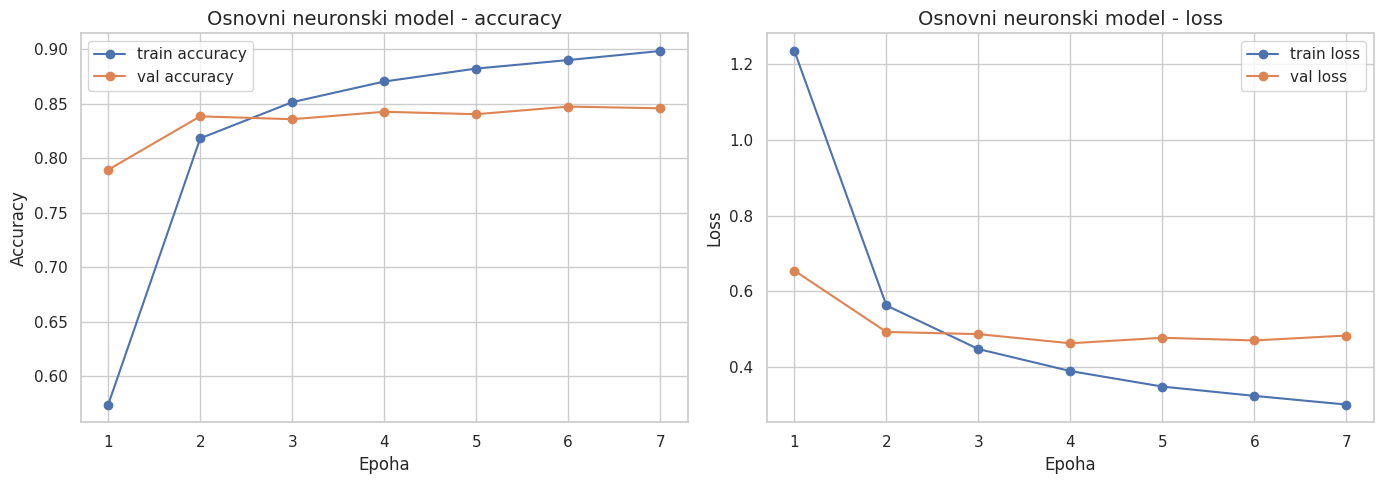

Model: Osnovni neuronski model
                       precision    recall  f1-score   support

               Access       0.76      0.94      0.84      1069
Administrative rights       0.87      0.63      0.73       264
           HR Support       0.89      0.82      0.85      1638
             Hardware       0.81      0.87      0.84      2042
     Internal Project       0.96      0.71      0.81       318
        Miscellaneous       0.83      0.80      0.81      1059
             Purchase       0.98      0.88      0.93       370
              Storage       0.95      0.82      0.88       416

             accuracy                           0.84      7176
            macro avg       0.88      0.81      0.84      7176
         weighted avg       0.85      0.84      0.84      7176



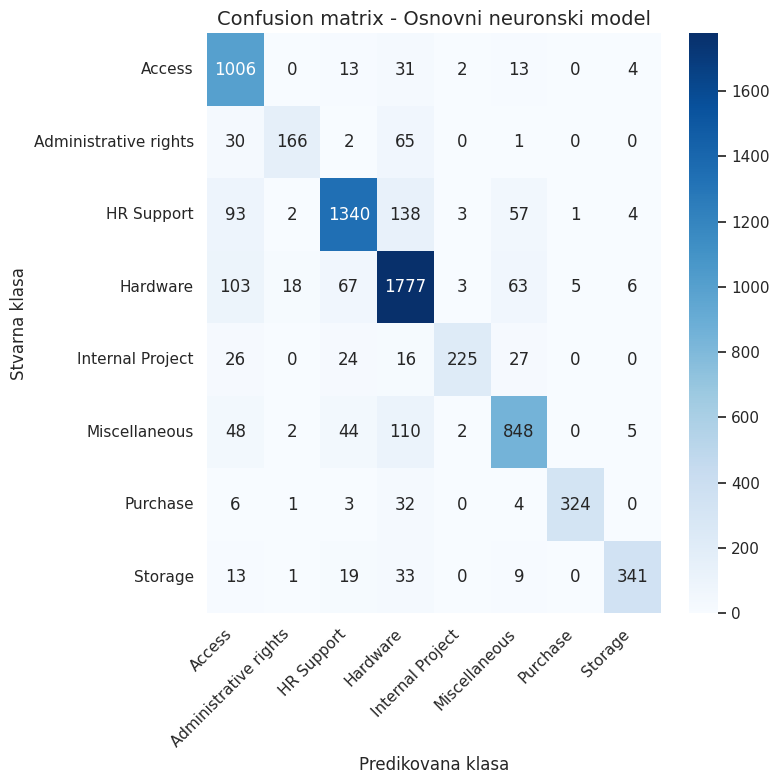

In [ ]:
basic_model = build_basic_nn_model(
    vectorizer=vectorizer,
    max_tokens=MAX_TOKENS,
    num_classes=num_classes,
    embedding_dim=64,
    dense_units=64,
    dropout_rate=0.3,
)

basic_model.summary()

basic_checkpoint_path = MODELS_DIR / "best_basic_nn.keras"
basic_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=basic_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

basic_history = basic_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=basic_callbacks,
    verbose=1,
)

history_store["Osnovni neuronski model"] = basic_history.history
plot_training_history(
    basic_history,
    "Osnovni neuronski model",
    PLOTS_DIR / "basic_nn_training_history.png",
)

basic_model = tf.keras.models.load_model(basic_checkpoint_path)
basic_result, basic_y_pred, basic_probabilities = evaluate_model(
    basic_model,
    X_test,
    y_test,
    label_names,
    "Osnovni neuronski model",
    PLOTS_DIR / "basic_nn_confusion_matrix.png",
)

results.append(basic_result)

best_model_path = MODELS_DIR / "best_ticket_classifier.keras"
basic_model.save(best_model_path)

best_neural_result = basic_result.copy()
best_neural_model_name = "Osnovni neuronski model"
best_model_config = {
    "name": "Osnovni neuronski model",
    "model_type": "dense",
    "embedding_dim": 64,
    "dense_units": 64,
    "dropout_rate": 0.3,
    "sequence_length": SEQUENCE_LENGTH,
    "max_tokens": MAX_TOKENS,
    "dataset_slug": KAGGLE_DATASET,
    "text_column": TEXT_COLUMN,
    "label_column": LABEL_COLUMN,
}


## 14. Eksperimenti

U ovoj sekciji menjamo nekoliko važnih hiperparametara:
- dimenziju `Embedding` sloja,
- broj neurona u gustim slojevima,
- `dropout`,
- dužinu sekvence.

Pošto `sequence_length` menja oblik ulaza, za svaki eksperiment pravimo novi `TextVectorization` sloj i adaptiramo ga samo na trening tekstovima.


Pokreće se eksperiment: NN_emb32_dense64_dropout03_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5260 - loss: 1.3589 - val_accuracy: 0.7441 - val_loss: 0.8112
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7939 - loss: 0.6539 - val_accuracy: 0.8166 - val_loss: 0.5649
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8413 - loss: 0.4936 - val_accuracy: 0.8347 - val_loss: 0.5034
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8612 - loss: 0.4247 - val_accuracy: 0.8339 - val_loss: 0.4961
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8760 - loss: 0.3768 - val_accuracy: 0.8370 - val_loss: 0.4862
Epoch 6/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8856 - loss: 0.3464 - val_accuracy: 0.8425 - val_loss: 0.4714
Epoch 7/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8932 - loss: 0.3220 - val_accuracy: 0.8407 - val_loss: 0.4783
Epoch 8/10
1047/1047 ━━━━━━━━━━━

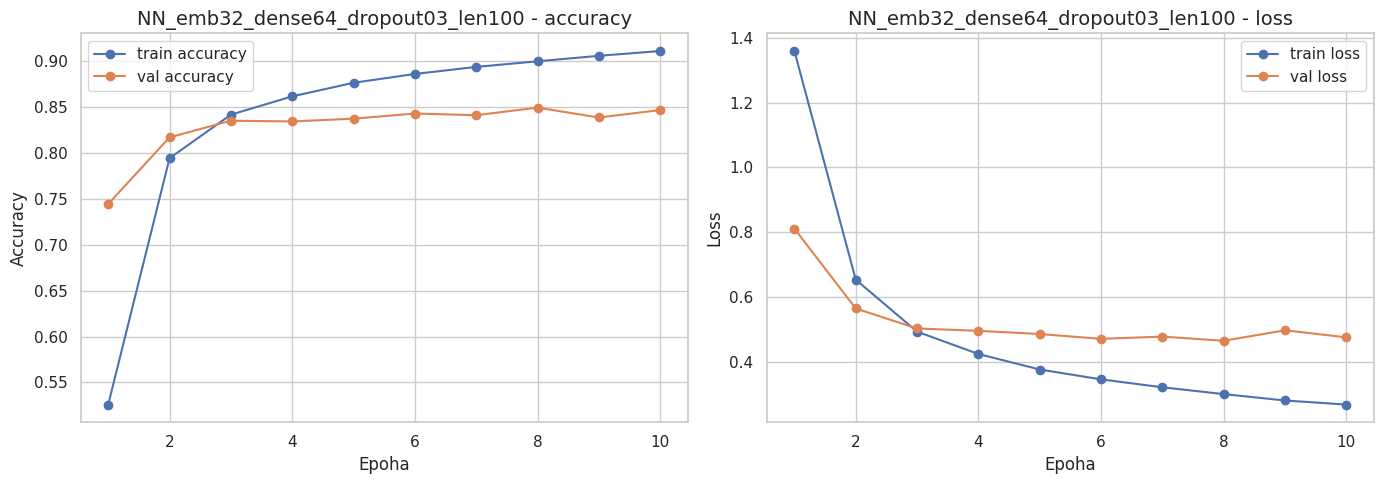

Model: NN_emb32_dense64_dropout03_len100
                       precision    recall  f1-score   support

               Access       0.84      0.92      0.88      1069
Administrative rights       0.85      0.65      0.74       264
           HR Support       0.86      0.84      0.85      1638
             Hardware       0.79      0.88      0.83      2042
     Internal Project       0.93      0.73      0.82       318
        Miscellaneous       0.83      0.80      0.82      1059
             Purchase       0.98      0.87      0.92       370
              Storage       0.96      0.80      0.87       416

             accuracy                           0.84      7176
            macro avg       0.88      0.81      0.84      7176
         weighted avg       0.85      0.84      0.84      7176



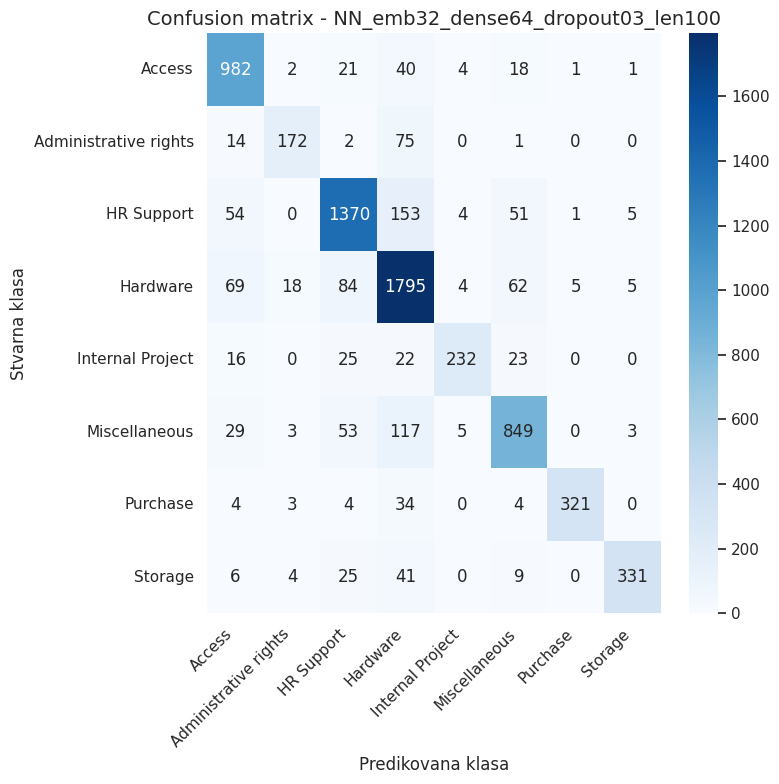

Pokreće se eksperiment: NN_emb64_dense64_dropout03_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5687 - loss: 1.2399 - val_accuracy: 0.7755 - val_loss: 0.6729
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8171 - loss: 0.5604 - val_accuracy: 0.8292 - val_loss: 0.5201
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8525 - loss: 0.4492 - val_accuracy: 0.8363 - val_loss: 0.4858
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8693 - loss: 0.3930 - val_accuracy: 0.8350 - val_loss: 0.4969
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8821 - loss: 0.3561 - val_accuracy: 0.8304 - val_loss: 0.5131


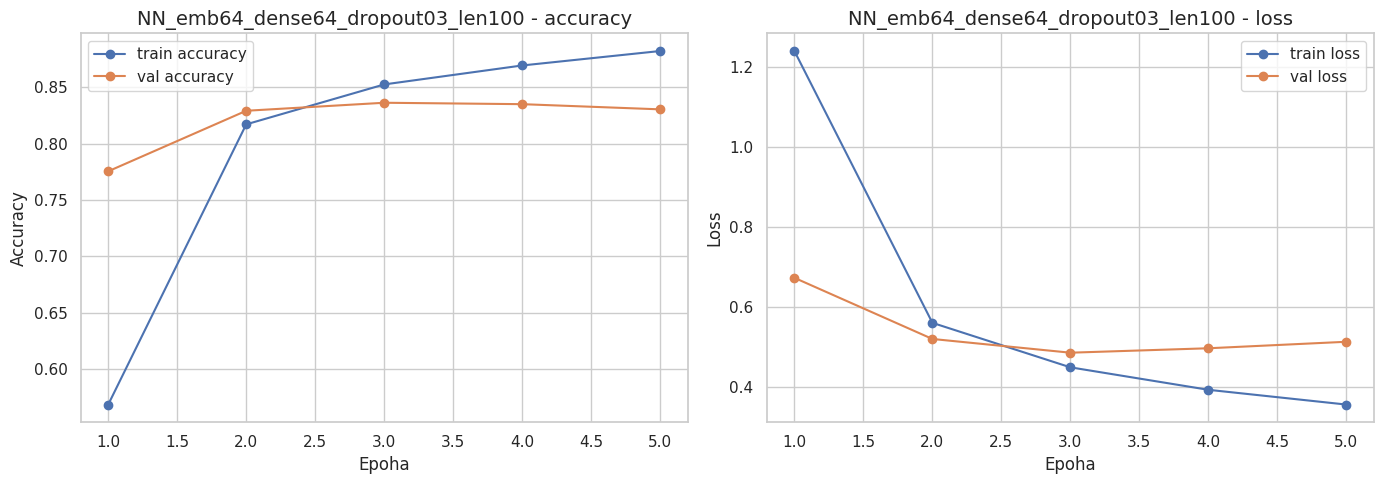

Model: NN_emb64_dense64_dropout03_len100
                       precision    recall  f1-score   support

               Access       0.82      0.91      0.86      1069
Administrative rights       0.87      0.51      0.64       264
           HR Support       0.86      0.83      0.84      1638
             Hardware       0.77      0.89      0.82      2042
     Internal Project       0.96      0.67      0.79       318
        Miscellaneous       0.82      0.79      0.80      1059
             Purchase       0.99      0.84      0.91       370
              Storage       0.96      0.77      0.85       416

             accuracy                           0.83      7176
            macro avg       0.88      0.78      0.82      7176
         weighted avg       0.84      0.83      0.83      7176



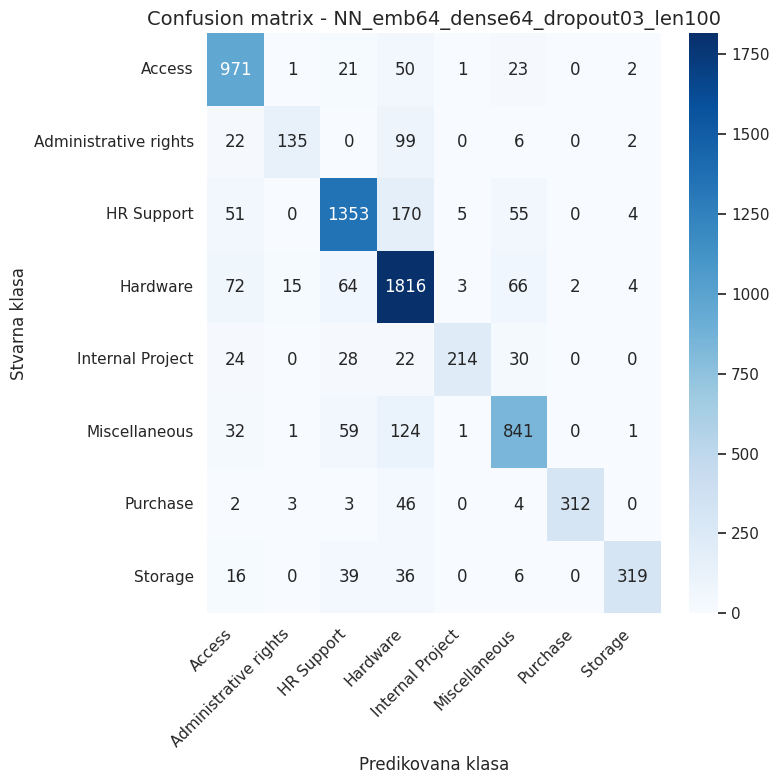

Pokreće se eksperiment: NN_emb128_dense128_dropout05_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6120 - loss: 1.1192 - val_accuracy: 0.7932 - val_loss: 0.6306
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8278 - loss: 0.5217 - val_accuracy: 0.8346 - val_loss: 0.5156
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8595 - loss: 0.4253 - val_accuracy: 0.8328 - val_loss: 0.4999
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8749 - loss: 0.3742 - val_accuracy: 0.8322 - val_loss: 0.5180
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8859 - loss: 0.3389 - val_accuracy: 0.8220 - val_loss: 0.5198


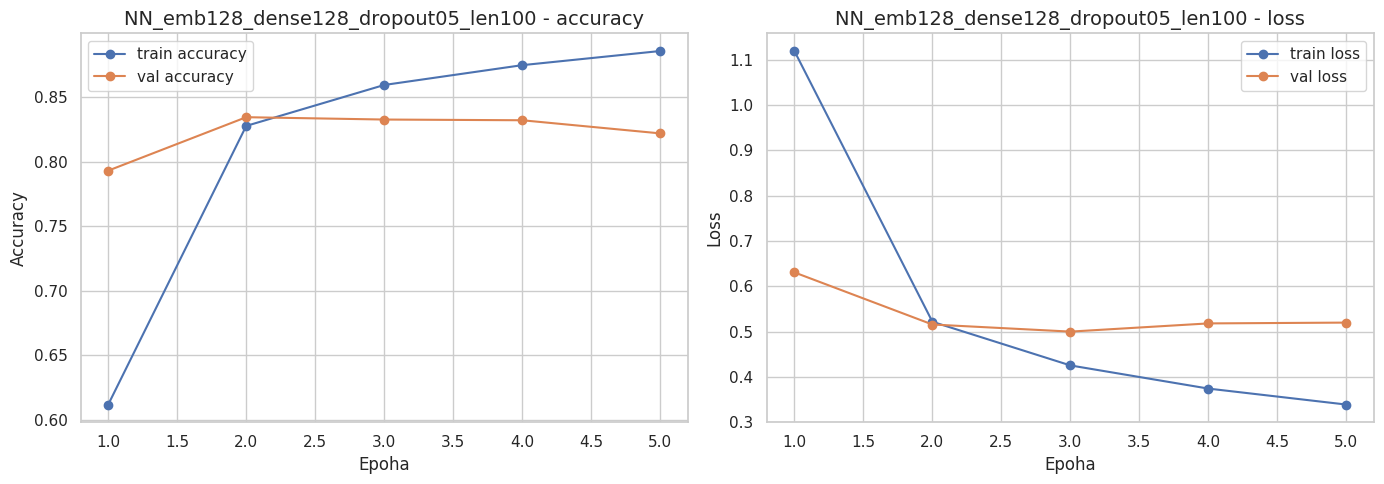

Model: NN_emb128_dense128_dropout05_len100
                       precision    recall  f1-score   support

               Access       0.73      0.94      0.82      1069
Administrative rights       0.91      0.57      0.70       264
           HR Support       0.86      0.84      0.85      1638
             Hardware       0.81      0.85      0.83      2042
     Internal Project       0.96      0.68      0.79       318
        Miscellaneous       0.83      0.80      0.81      1059
             Purchase       0.99      0.87      0.93       370
              Storage       0.97      0.75      0.85       416

             accuracy                           0.83      7176
            macro avg       0.88      0.79      0.82      7176
         weighted avg       0.84      0.83      0.83      7176



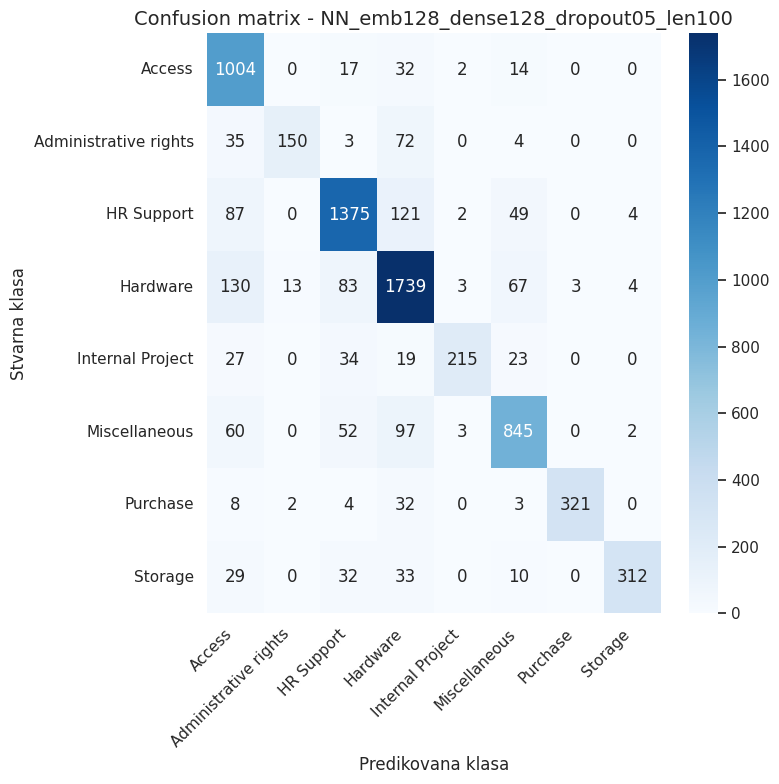

Pokreće se eksperiment: NN_emb64_dense128_dropout05_len150
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5127 - loss: 1.3679 - val_accuracy: 0.7860 - val_loss: 0.7573
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7929 - loss: 0.6477 - val_accuracy: 0.7878 - val_loss: 0.6306
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8323 - loss: 0.5143 - val_accuracy: 0.8064 - val_loss: 0.5549
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8530 - loss: 0.4454 - val_accuracy: 0.8122 - val_loss: 0.5556
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8628 - loss: 0.4095 - val_accuracy: 0.8109 - val_loss: 0.5580


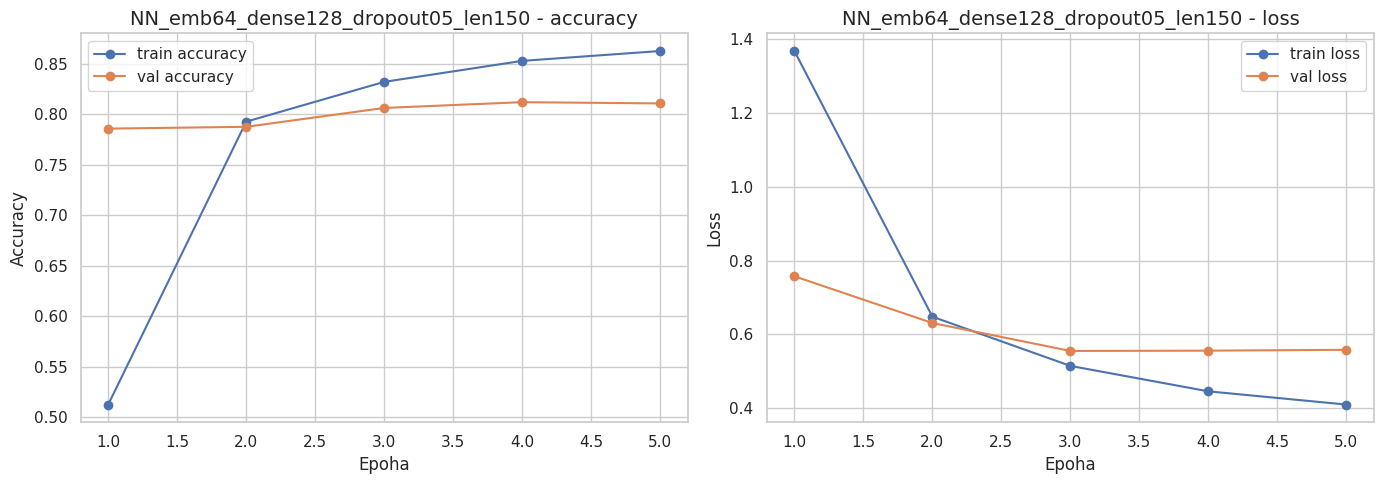

Model: NN_emb64_dense128_dropout05_len150
                       precision    recall  f1-score   support

               Access       0.80      0.91      0.85      1069
Administrative rights       0.83      0.45      0.59       264
           HR Support       0.90      0.71      0.80      1638
             Hardware       0.69      0.92      0.79      2042
     Internal Project       0.96      0.63      0.76       318
        Miscellaneous       0.83      0.76      0.80      1059
             Purchase       0.98      0.86      0.92       370
              Storage       0.97      0.72      0.83       416

             accuracy                           0.80      7176
            macro avg       0.87      0.75      0.79      7176
         weighted avg       0.83      0.80      0.80      7176



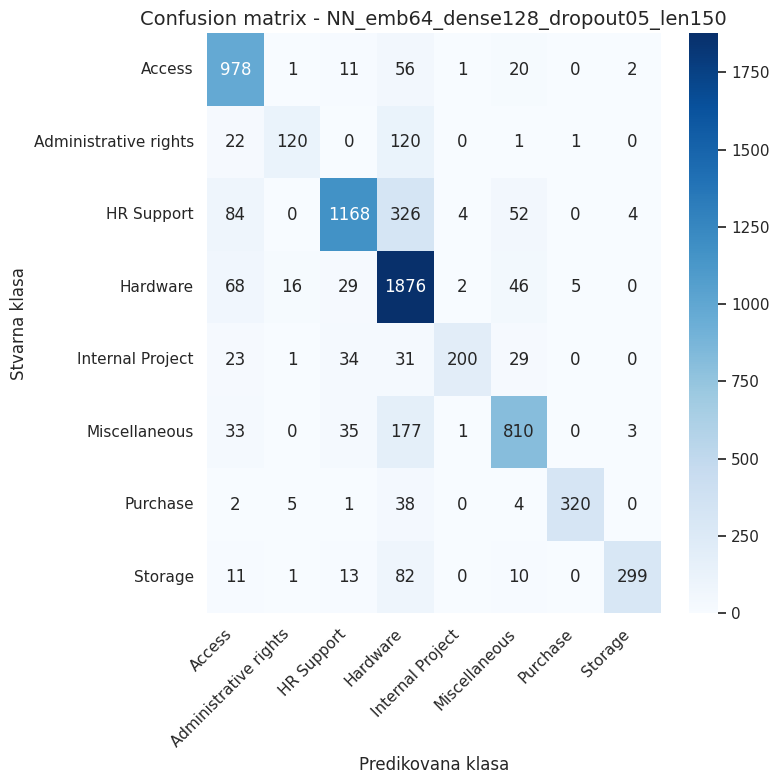

In [ ]:
experiment_configs = [
    {
        "name": "NN_emb32_dense64_dropout03_len100",
        "embedding_dim": 32,
        "dense_units": 64,
        "dropout_rate": 0.3,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb64_dense64_dropout03_len100",
        "embedding_dim": 64,
        "dense_units": 64,
        "dropout_rate": 0.3,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb128_dense128_dropout05_len100",
        "embedding_dim": 128,
        "dense_units": 128,
        "dropout_rate": 0.5,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb64_dense128_dropout05_len150",
        "embedding_dim": 64,
        "dense_units": 128,
        "dropout_rate": 0.5,
        "sequence_length": 150,
    },
]

for config in experiment_configs:
    print("=" * 80)
    print(f"Pokreće se eksperiment: {config['name']}")

    experiment_vectorizer = create_vectorizer(
        X_train,
        max_tokens=MAX_TOKENS,
        sequence_length=config["sequence_length"],
    )

    experiment_model = build_experiment_model(
        vectorizer=experiment_vectorizer,
        max_tokens=MAX_TOKENS,
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        dense_units=config["dense_units"],
        dropout_rate=config["dropout_rate"],
    )

    experiment_checkpoint_path = MODELS_DIR / f"{config['name']}.keras"
    experiment_callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        ),
        ModelCheckpoint(
            filepath=experiment_checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    experiment_history = experiment_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        callbacks=experiment_callbacks,
        verbose=1,
    )

    history_store[config["name"]] = experiment_history.history
    plot_training_history(
        experiment_history,
        config["name"],
        PLOTS_DIR / f"{config['name']}_history.png",
    )

    experiment_model = tf.keras.models.load_model(experiment_checkpoint_path)
    experiment_result, _, _ = evaluate_model(
        experiment_model,
        X_test,
        y_test,
        label_names,
        config["name"],
        PLOTS_DIR / f"{config['name']}_confusion_matrix.png",
    )

    results.append(experiment_result)

    if is_better_result(experiment_result, best_neural_result):
        best_neural_result = experiment_result.copy()
        best_neural_model_name = config["name"]
        best_model_config = {
            **config,
            "model_type": "dense",
            "max_tokens": MAX_TOKENS,
            "dataset_slug": KAGGLE_DATASET,
            "text_column": TEXT_COLUMN,
            "label_column": LABEL_COLUMN,
        }
        experiment_model.save(best_model_path)


## 15. CNN model za tekstualnu klasifikaciju

Kao dodatni eksperiment implementiramo i jednostavan `CNN` model. Ideja je da konvolucioni sloj može da nauči lokalne obrasce u tekstu, na primer kratke kombinacije reči koje se često pojavljuju u određenim tipovima tiketa.


Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7117 - loss: 0.8453 - val_accuracy: 0.8392 - val_loss: 0.4545
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8641 - loss: 0.4128 - val_accuracy: 0.8435 - val_loss: 0.4330
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9053 - loss: 0.2907 - val_accuracy: 0.8428 - val_loss: 0.4480
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9366 - loss: 0.2008 - val_accuracy: 0.8445 - val_loss: 0.4770


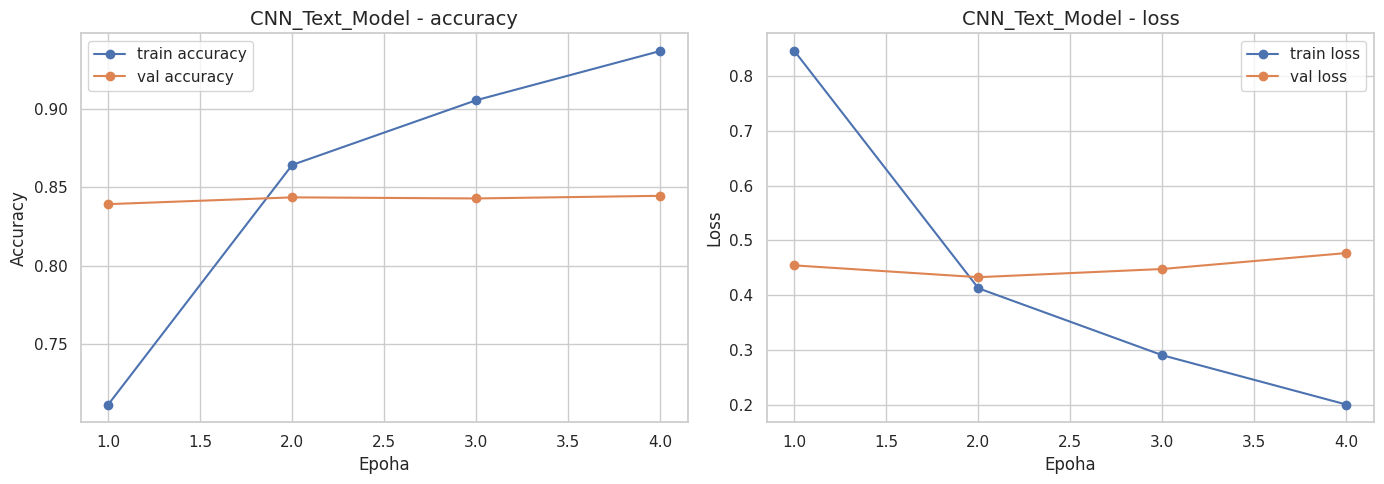

Model: CNN_Text_Model
                       precision    recall  f1-score   support

               Access       0.88      0.87      0.87      1069
Administrative rights       0.80      0.74      0.77       264
           HR Support       0.86      0.86      0.86      1638
             Hardware       0.82      0.85      0.83      2042
     Internal Project       0.90      0.86      0.88       318
        Miscellaneous       0.82      0.80      0.81      1059
             Purchase       0.91      0.89      0.90       370
              Storage       0.89      0.88      0.89       416

             accuracy                           0.85      7176
            macro avg       0.86      0.84      0.85      7176
         weighted avg       0.85      0.85      0.85      7176



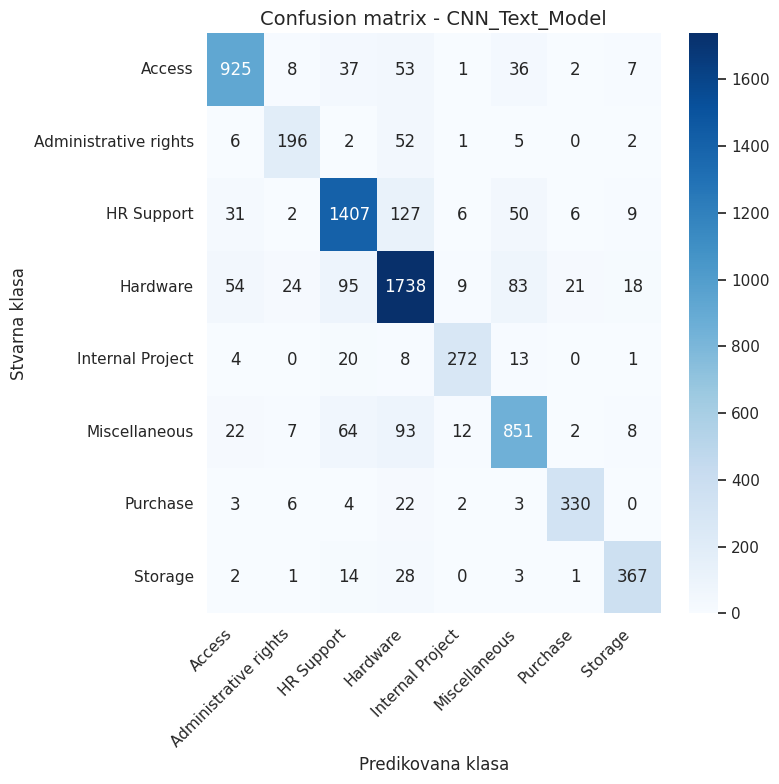

In [ ]:
cnn_config = {
    "name": "CNN_Text_Model",
    "embedding_dim": 64,
    "filters": 64,
    "kernel_size": 5,
    "dense_units": 64,
    "dropout_rate": 0.4,
    "sequence_length": 120,
}

cnn_vectorizer = create_vectorizer(
    X_train,
    max_tokens=MAX_TOKENS,
    sequence_length=cnn_config["sequence_length"],
)

cnn_model = build_cnn_model(
    vectorizer=cnn_vectorizer,
    max_tokens=MAX_TOKENS,
    num_classes=num_classes,
    embedding_dim=cnn_config["embedding_dim"],
    filters=cnn_config["filters"],
    kernel_size=cnn_config["kernel_size"],
    dense_units=cnn_config["dense_units"],
    dropout_rate=cnn_config["dropout_rate"],
)

cnn_checkpoint_path = MODELS_DIR / "cnn_text_model.keras"
cnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=cnn_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=cnn_callbacks,
    verbose=1,
)

history_store[cnn_config["name"]] = cnn_history.history
plot_training_history(
    cnn_history,
    cnn_config["name"],
    PLOTS_DIR / "cnn_text_model_history.png",
)

cnn_model = tf.keras.models.load_model(cnn_checkpoint_path)
cnn_result, _, _ = evaluate_model(
    cnn_model,
    X_test,
    y_test,
    label_names,
    cnn_config["name"],
    PLOTS_DIR / "cnn_text_model_confusion_matrix.png",
)

results.append(cnn_result)

if is_better_result(cnn_result, best_neural_result):
    best_neural_result = cnn_result.copy()
    best_neural_model_name = cnn_config["name"]
    best_model_config = {
        **cnn_config,
        "model_type": "cnn",
        "max_tokens": MAX_TOKENS,
        "dataset_slug": KAGGLE_DATASET,
        "text_column": TEXT_COLUMN,
        "label_column": LABEL_COLUMN,
    }
    cnn_model.save(best_model_path)


## 16. Poređenje svih modela

Sada na jednom mestu poređujemo baseline model, osnovni neuralni model i dodatne eksperimente. Poređenje radimo po `accuracy` i `F1 macro` metrici, jer je `F1 macro` posebno važan kada klase nisu savršeno izbalansirane.


,model,accuracy,precision_macro,recall_macro,f1_macro
0,CNN_Text_Model,0.848105,0.859718,0.843857,0.851503
1,TF-IDF + Logistic Regression,0.851867,0.834155,0.873633,0.850608
2,NN_emb32_dense64_dropout03_len100,0.843367,0.880722,0.810007,0.840171
3,Osnovni neuronski model,0.839883,0.880300,0.807730,0.836655
4,NN_emb128_dense128_dropout05_len100,0.830686,0.881810,0.786253,0.822066
5,NN_emb64_dense64_dropout03_len100,0.830686,0.880553,0.776524,0.816570
6,NN_emb64_dense128_dropout05_len150,0.804208,0.872445,0.747326,0.791719


Tabela rezultata je sačuvana u: outputs/model_results.csv


/tmp/ipykernel_14802/1961588896.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="accuracy", y="model", palette="Blues_r")


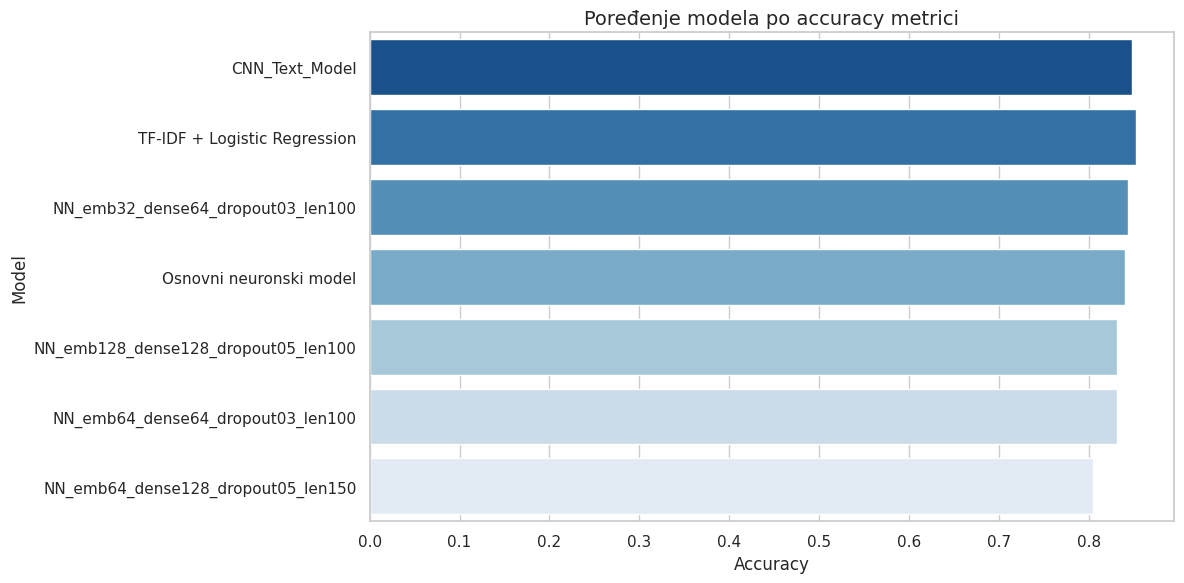

/tmp/ipykernel_14802/1961588896.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="f1_macro", y="model", palette="Greens_r")


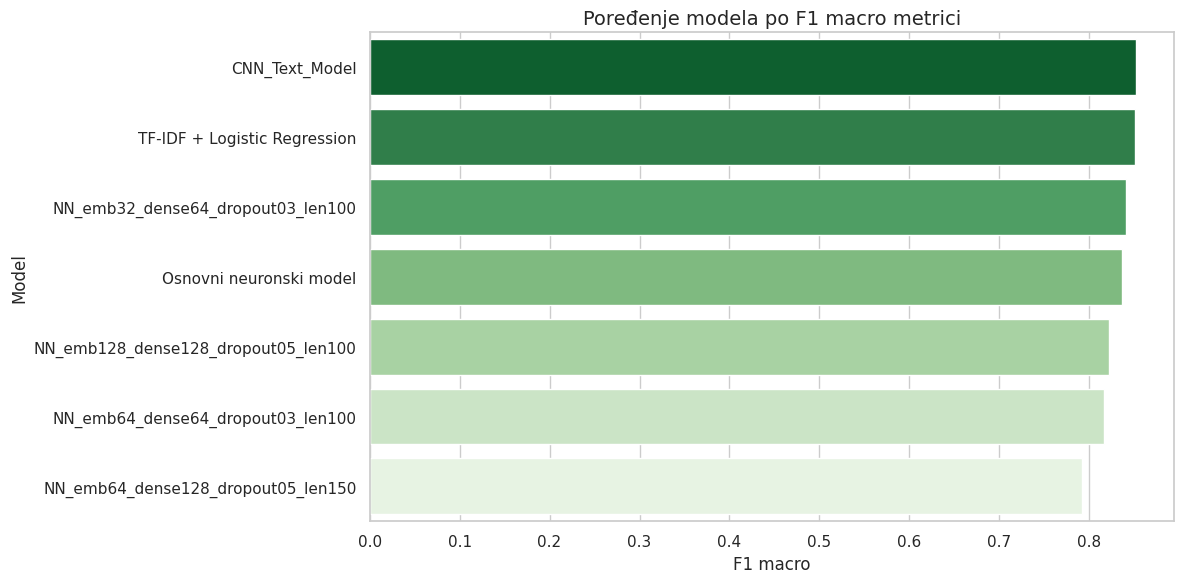

Najbolji neuralni model: CNN_Text_Model
Najbolja neuralna metrika: F1 macro = 0.8515
Konfiguracija najboljeg modela je sačuvana u: models/best_model_config.json
Najbolji model je sačuvan u: models/best_ticket_classifier.keras


In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(results_df)

results_df.to_csv(OUTPUTS_DIR / "model_results.csv", index=False)
print(f"Tabela rezultata je sačuvana u: {OUTPUTS_DIR / 'model_results.csv'}")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="accuracy", y="model", palette="Blues_r")
plt.title("Poređenje modela po accuracy metrici")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="f1_macro", y="model", palette="Greens_r")
plt.title("Poređenje modela po F1 macro metrici")
plt.xlabel("F1 macro")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_f1.png", dpi=150, bbox_inches="tight")
plt.show()

with open(MODELS_DIR / "best_model_config.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            **best_model_config,
            "best_metrics": best_neural_result,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print(f"Najbolji neuralni model: {best_neural_model_name}")
print(f"Najbolja neuralna metrika: F1 macro = {best_neural_result['f1_macro']:.4f}")
print(f"Konfiguracija najboljeg modela je sačuvana u: {MODELS_DIR / 'best_model_config.json'}")
print(f"Najbolji model je sačuvan u: {best_model_path}")


## 17. Evaluacija najboljeg sačuvanog modela

Pošto je najbolji model sačuvan u `.keras` formatu zajedno sa `TextVectorization` slojem, možemo ga direktno ponovo učitati i proveriti na test skupu. Ovo je važno jer pokazuje da model može da primi sirov tekst bez dodatne ručne obrade tokena.


Model: Najbolji sačuvani model - CNN_Text_Model
                       precision    recall  f1-score   support

               Access       0.88      0.87      0.87      1069
Administrative rights       0.80      0.74      0.77       264
           HR Support       0.86      0.86      0.86      1638
             Hardware       0.82      0.85      0.83      2042
     Internal Project       0.90      0.86      0.88       318
        Miscellaneous       0.82      0.80      0.81      1059
             Purchase       0.91      0.89      0.90       370
              Storage       0.89      0.88      0.89       416

             accuracy                           0.85      7176
            macro avg       0.86      0.84      0.85      7176
         weighted avg       0.85      0.85      0.85      7176



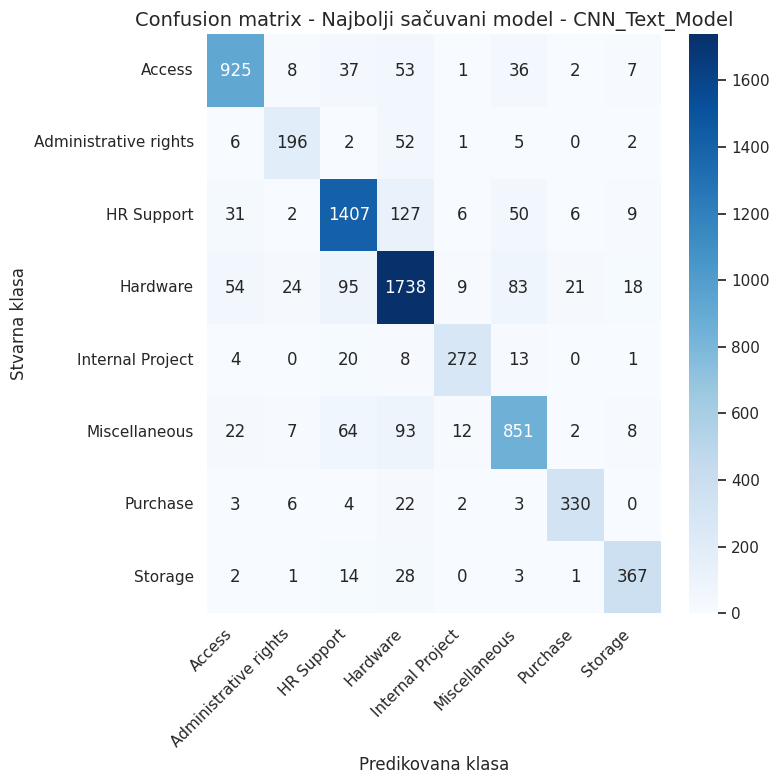

{'model': 'Najbolji sačuvani model - CNN_Text_Model',
 'accuracy': 0.8481047937569677,
 'precision_macro': 0.8597178977522799,
 'recall_macro': 0.8438571561468717,
 'f1_macro': 0.8515030021016059}

In [ ]:
best_saved_model = tf.keras.models.load_model(best_model_path)
best_saved_result, best_saved_y_pred, best_saved_probabilities = evaluate_model(
    best_saved_model,
    X_test,
    y_test,
    label_names,
    f"Najbolji sačuvani model - {best_neural_model_name}",
    PLOTS_DIR / "best_saved_model_confusion_matrix.png",
)

best_saved_result


## 18. Predikcija novih tiketa

Na kraju pravimo funkciju koja prima novi tekst tiketa, čisti ga istom logikom kao i trening podaci, pokreće model i vraća:
- predviđenu kategoriju,
- procenat pouzdanosti,
- top-k najverovatnijih kategorija.


In [35]:
with open(MODELS_DIR / "label_mapping.json", "r", encoding="utf-8") as file:
    saved_label_mapping = json.load(file)


def predict_ticket_category(text, model, label_mapping, top_k=3):
    cleaned_text = clean_text(text)
    if not cleaned_text:
        raise ValueError("Ulazni tekst je prazan nakon čišćenja.")

    input_tensor = tf.constant([cleaned_text], dtype=tf.string)
    probabilities = model.predict(input_tensor, verbose=0)[0]
    top_indices = probabilities.argsort()[::-1][:top_k]

    predictions = []
    for index in top_indices:
        predictions.append(
            {
                "category": label_mapping["id_to_label"][str(int(index))],
                "probability": float(probabilities[index]),
            }
        )

    return {
        "input_text": text,
        "clean_text": cleaned_text,
        "predicted_category": predictions[0]["category"],
        "confidence": predictions[0]["probability"],
        "top_k_predictions": predictions,
    }


example_tickets = [
    "I cannot enter my profile after password reset.",
    "Printer is not working after update.",
    "VPN connection keeps disconnecting.",
    "My email inbox is not receiving messages.",
    "Application crashes when I try to open it.",
]

for example_text in example_tickets:
    prediction = predict_ticket_category(
        example_text,
        best_saved_model,
        saved_label_mapping,
        top_k=3,
    )

    print("=" * 80)
    print(f"Input: {prediction['input_text']}")
    print(f"Očišćen tekst: {prediction['clean_text']}")
    print(f"Predicted category: {prediction['predicted_category']}")
    print(f"Confidence: {prediction['confidence'] * 100:.2f}%")
    print("Top 3 predikcije:")
    for rank, item in enumerate(prediction["top_k_predictions"], start=1):
        print(f"{rank}. {item['category']} - {item['probability'] * 100:.2f}%")


Input: I cannot enter my profile after password reset.
Očišćen tekst: i cannot enter my profile after password reset
Predicted category: Access
Confidence: 98.48%
Top 3 predikcije:
1. Access - 98.48%
2. Hardware - 1.36%
3. Administrative rights - 0.10%
Input: Printer is not working after update.
Očišćen tekst: printer is not working after update
Predicted category: Hardware
Confidence: 50.67%
Top 3 predikcije:
1. Hardware - 50.67%
2. Administrative rights - 36.89%
3. Access - 6.33%
Input: VPN connection keeps disconnecting.
Očišćen tekst: vpn connection keeps disconnecting
Predicted category: Hardware
Confidence: 87.73%
Top 3 predikcije:
1. Hardware - 87.73%
2. Administrative rights - 10.00%
3. Access - 1.15%
Input: My email inbox is not receiving messages.
Očišćen tekst: my email inbox is not receiving messages
Predicted category: Hardware
Confidence: 76.08%
Top 3 predikcije:
1. Hardware - 76.08%
2. Administrative rights - 10.25%
3. Purchase - 9.26%
Input: Application crashes when I t

## 19. Zakljucak

U ovom projektu prikazan je kompletan tok rada za klasifikaciju IT support tiketa:
1. Kaggle API je podesen direktno iz notebook-a.
2. Dataset je preuzet direktno u runtime okruzenje.
3. CSV fajl je pronadjen, ucitan i analiziran.
4. Tekstualni podaci su ocisceni i pripremljeni za modelovanje.
5. Kategorije su pretvorene u numericki oblik.
6. Napravljeni su baseline model i vise neuralnih eksperimenata.
7. Najbolji model je sacuvan i moze da predvidja kategoriju novih tiketa.

Na osnovu konacnih metrika i confusion matrix prikaza moguce je proceniti:
- da li neuronska mreza daje bolji rezultat od baseline modela,
- koje kategorije model najcesce mesa,
- da li postoji overfitting,
- koji skup hiperparametara daje najbolji rezultat.


In [36]:
best_overall_row = results_df.iloc[0]
baseline_row = results_df[results_df["model"] == "TF-IDF + Logistic Regression"].iloc[0]
best_neural_row = (
    results_df[results_df["model"] != "TF-IDF + Logistic Regression"]
    .sort_values(by=["f1_macro", "accuracy"], ascending=False)
    .iloc[0]
)

best_history = history_store.get(best_neural_model_name, {})
overfitting_note = "Nije moguće proceniti overfitting bez istorije treninga."
if best_history:
    train_acc_last = best_history.get("accuracy", [None])[-1]
    val_acc_last = best_history.get("val_accuracy", [None])[-1]
    if train_acc_last is not None and val_acc_last is not None:
        acc_gap = train_acc_last - val_acc_last
        if acc_gap > 0.08:
            overfitting_note = (
                f"Postoji signal mogućeg overfitting-a jer je razlika između train i validation accuracy oko {acc_gap:.3f}."
            )
        else:
            overfitting_note = (
                f"Ne vidi se izražen overfitting, jer je razlika između train i validation accuracy oko {acc_gap:.3f}."
            )

cm_best_model = confusion_matrix(
    y_test,
    best_saved_y_pred,
    labels=list(range(len(label_names))),
)
np.fill_diagonal(cm_best_model, 0)

if cm_best_model.max() > 0:
    row_index, col_index = np.unravel_index(cm_best_model.argmax(), cm_best_model.shape)
    confusion_note = (
        f"Najčešća zamena je između kategorija '{label_names[row_index]}' i '{label_names[col_index]}'."
    )
else:
    confusion_note = "Na confusion matrix prikazu nema izražene dominantne zamene između dve klase."

neural_vs_baseline = "bolji" if best_neural_row["f1_macro"] >= baseline_row["f1_macro"] else "slabiji"

summary_markdown = (
    "### Kratak završni rezime\n\n"
    f"- Najbolji model u celom poređenju je **{best_overall_row['model']}**.\n"
    f"- Najbolji neuronski model je **{best_neural_model_name}** sa `F1 macro = {best_neural_row['f1_macro']:.4f}` i `accuracy = {best_neural_row['accuracy']:.4f}`.\n"
    f"- U odnosu na baseline model, najbolji neuronski model je **{neural_vs_baseline}** po `F1 macro` metrici.\n"
    f"- {overfitting_note}\n"
    f"- {confusion_note}"
)
display(Markdown(summary_markdown))


### Kratak završni rezime

- Najbolji model u celom poređenju je **CNN_Text_Model**.
- Najbolji neuronski model je **CNN_Text_Model** sa `F1 macro = 0.8515` i `accuracy = 0.8481`.
- U odnosu na baseline model, najbolji neuronski model je **bolji** po `F1 macro` metrici.
- Postoji signal mogućeg overfitting-a jer je razlika između train i validation accuracy oko 0.092.
- Najčešća zamena je između kategorija 'HR Support' i 'Hardware'.